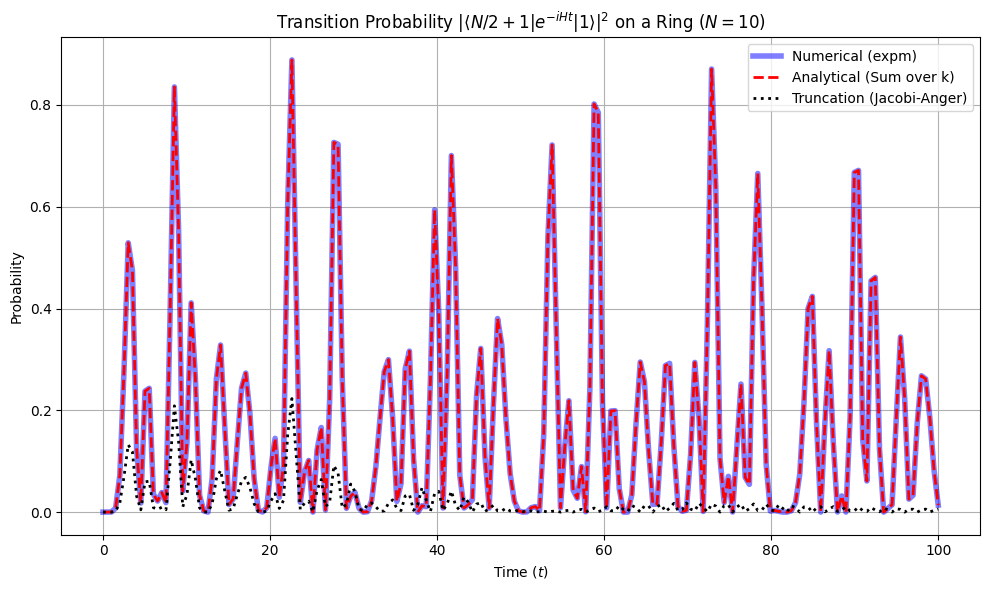

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm
from scipy.special import jv

def simulate_quantum_ring(N=10, gamma=1.0, t_max=80.0, time_steps=200):
    # Ensure N is even
    assert N % 2 == 0, "N must be an even number."

    times = np.linspace(0, t_max, time_steps)

    # 1. Construct the Hamiltonian H = D - A
    H = np.zeros((N, N))
    for i in range(N):
        H[i, i] = 2.0
        H[i, (i + 1) % N] = -1.0
        H[i, (i - 1) % N] = -1.0
    H = gamma * H

    # Indices (0-indexed in Python, so |1> is index 0, |N/2+1> is index N/2)
    start_idx = 0
    target_idx = N // 2

    # Initial state |start> = |1>
    psi_0 = np.zeros(N)
    psi_0[start_idx] = 1.0

    # Arrays to store probabilities
    prob_num = np.zeros(time_steps)
    prob_ana_sum = np.zeros(time_steps)
    prob_ana_bessel = np.zeros(time_steps)

    # Maximum n for truncating the Jacobi-Anger infinite sum
    max_n = 50

    for i, t in enumerate(times):
        # --- 1. NUMERICAL (Matrix Exponentiation) ---
        U = expm(-1j * H * t)
        psi_t = U @ psi_0
        prob_num[i] = np.abs(psi_t[target_idx])**2

        # --- 2. ANALYTICAL (Exact Sum) ---
        amp_sum = 0j
        for k in range(1, N + 1):
            amp_sum += ((-1)**k) * np.exp(1j * 2 * gamma * t * np.cos(2 * np.pi * k / N))
        amp_sum /= N
        prob_ana_sum[i] = np.abs(amp_sum)**2

        # --- 3. ANALYTICAL (Jacobi-Anger Expansion) ---
        amp_bessel = 0j
        for k in range(1, N + 1):
            # Evaluate the sum over n first
            bessel_sum = 0j
            for n in range(1, max_n):
                bessel_sum += (1j**n) * jv(n, 2 * gamma * t) * np.cos(n * 2 * np.pi * k / N)

            # Combine with J_0 term
            term_k = jv(0, 2 * gamma * t) + bessel_sum
            amp_bessel += ((-1)**k) * term_k

        amp_bessel /= N
        prob_ana_bessel[i] = np.abs(amp_bessel)**2

    # PLOT 
    plt.figure(figsize=(10, 6))
    plt.plot(times, prob_num, 'b-', linewidth=4, alpha=0.5, label='Numerical (expm)')
    plt.plot(times, prob_ana_sum, 'r--', linewidth=2, label='Analytical (Sum over k)')
    plt.plot(times, prob_ana_bessel, 'k:', linewidth=2, label='Truncation (Jacobi-Anger)')

    plt.title(f"Transition Probability $|\\langle N/2+1 | e^{{-iHt}} | 1 \\rangle|^2$ on a Ring ($N={N}$)")
    plt.xlabel("Time ($t$)")
    plt.ylabel("Probability")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Run the simulation
simulate_quantum_ring(N=10, gamma=1.0, t_max=100.0)


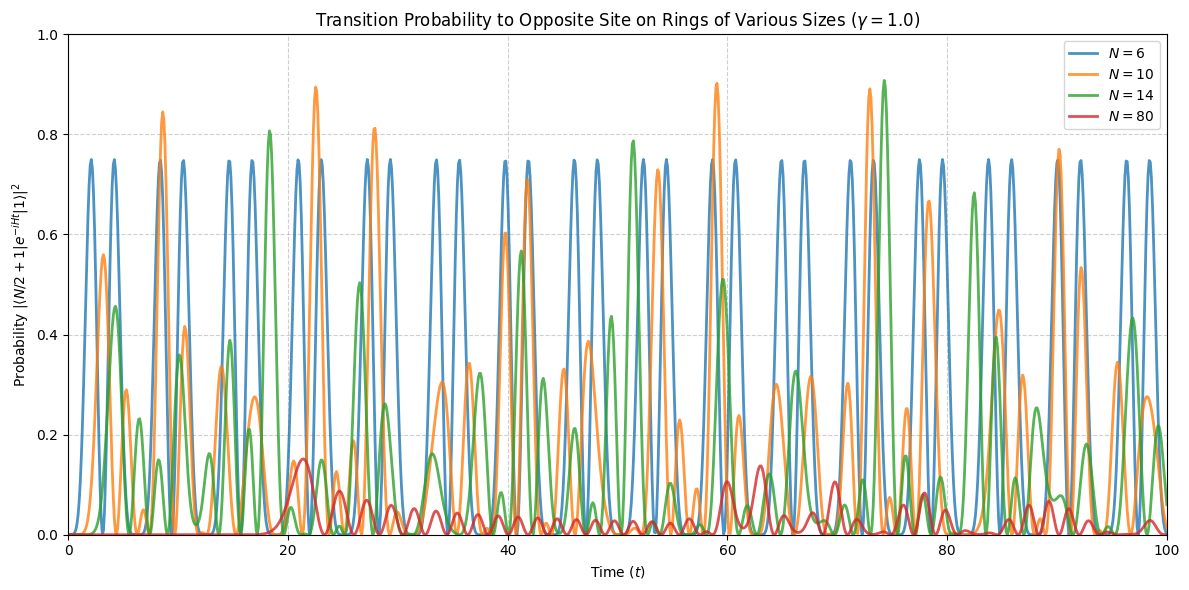

In [17]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_multiple_rings(N_list=[10, 20, 30, 50], gamma=1.0, t_max=100.0, time_steps=1000):
    # Array of time points
    times = np.linspace(0, t_max, time_steps)
    
    plt.figure(figsize=(12, 6))
    
    for N in N_list:
        if N % 2 != 0:
            print(f"Skipping N={N}: N must be even.")
            continue
            
        prob_ana_sum = np.zeros(time_steps)
        
        for i, t in enumerate(times):
            # Route 2: Analytical Summation
            amp_sum = 0j
            for k in range(1, N + 1):
                # Using the exact sum derived via QFT
                phase = 2 * gamma * t * np.cos(2 * np.pi * k / N)
                amp_sum += ((-1)**k) * np.exp(1j * phase)
            
            amp_sum /= N
            prob_ana_sum[i] = np.abs(amp_sum)**2
            
        # Plot the curve for the current N
        plt.plot(times, prob_ana_sum, label=f'$N = {N}$', linewidth=2, alpha=0.8)

    # Formatting the plot
    plt.title(f"Transition Probability to Opposite Site on Rings of Various Sizes ($\\gamma={gamma}$)")
    plt.xlabel("Time ($t$)")
    plt.ylabel("Probability $|\\langle N/2+1 | e^{-iHt} | 1 \\rangle|^2$")
    plt.xlim(0, t_max)
    plt.ylim(0, 1.0)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

# Run the simulation for some N's
simulate_multiple_rings(N_list=[6, 10, 14, 80], gamma=1.0, t_max=100.0)


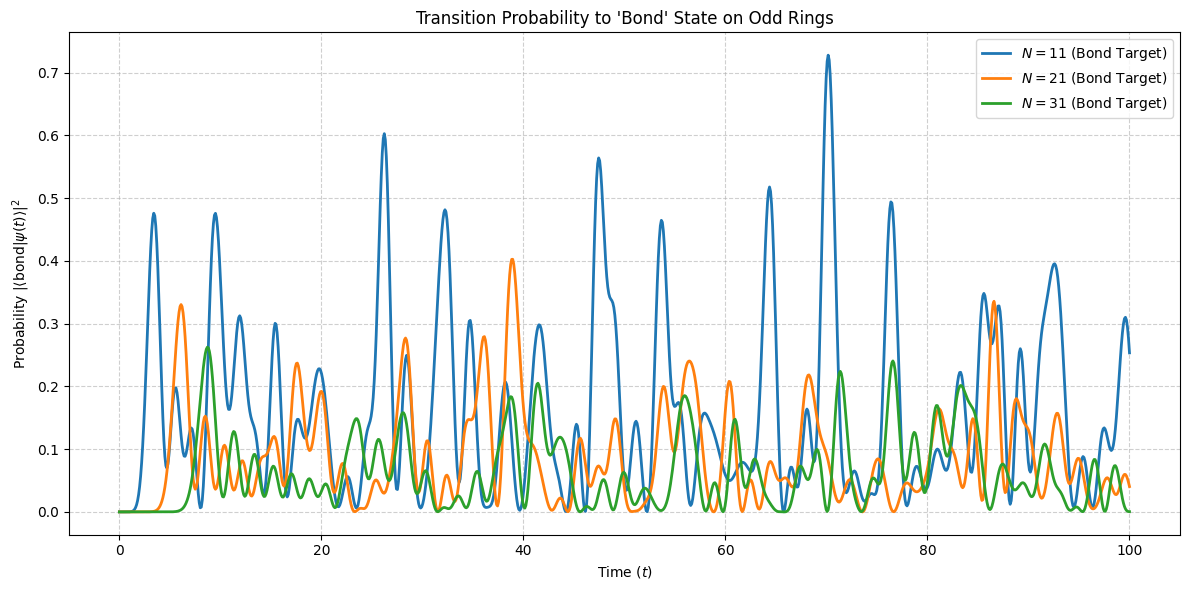

In [18]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_odd_ring_bond(N_list=[11, 21, 31], gamma=1.0, t_max=100.0, time_steps=1000):
    assert all(N % 2 != 0 for N in N_list), "All N must be odd."
    times = np.linspace(0, t_max, time_steps)
    
    plt.figure(figsize=(12, 6))
    
    for N in N_list:
        # Indices for the bond
        n_floor = N // 2  # This corresponds to |floor(N/2)+1> in 0-indexing
        
        prob_bond = np.zeros(time_steps)
        
        for i, t in enumerate(times):
            # We need amplitudes to n_floor and n_floor + 1
            # Using the general form: alpha = (1/N) * sum_k exp(-i E_k t) * exp(i 2pi k (n-m)/N)
            
            def get_amplitude(target_idx, start_idx=0):
                amp = 0j
                for k in range(N):
                    E_k = -2 * gamma * np.cos(2 * np.pi * k / N)
                    phase = -1j * E_k * t
                    spatial = np.exp(1j * 2 * np.pi * k * (target_idx - start_idx) / N)
                    amp += (1/N) * np.exp(phase) * spatial
                return amp

            # Target is 1/sqrt(2) * (|n_floor> + |n_floor+1>)
            # Amplitude is <end|psi(t)> = 1/sqrt(2) * (<n_floor| + <n_floor+1|) * |psi(t)>
            amp_n = get_amplitude(n_floor)
            amp_n_plus_1 = get_amplitude((n_floor + 1) % N)
            
            amp_total = (1 / np.sqrt(2)) * (amp_n + amp_n_plus_1)
            prob_bond[i] = np.abs(amp_total)**2
            
        plt.plot(times, prob_bond, label=f'$N={N}$ (Bond Target)', linewidth=2)

    plt.title("Transition Probability to 'Bond' State on Odd Rings")
    plt.xlabel("Time ($t$)")
    plt.ylabel("Probability $|\\langle \\text{bond} | \\psi(t) \\rangle|^2$")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Run the simulation
simulate_odd_ring_bond(N_list=[11, 21, 31])

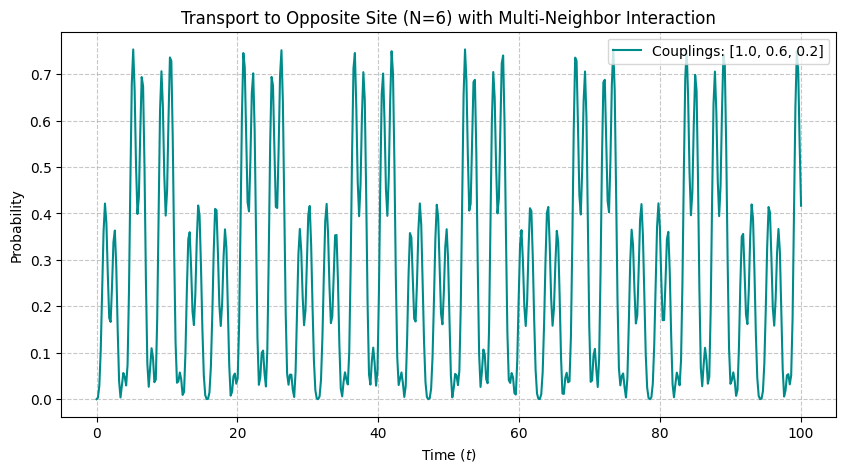

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

def simulate_connected_ring(N=6, gammas=[1.0, 0.0, 0.0], t_max=20.0, time_steps=500):
    """
    N: Number of sites (set to 6 as requested)
    gammas: List of couplings [gamma1, gamma2, gamma3, ...] 
            where index 0 is 1st neighbor, index 1 is 2nd neighbor, etc.
    """
    times = np.linspace(0, t_max, time_steps)
    
    # 1. Construct the Adjacency Matrix A and Degree Matrix D
    A = np.zeros((N, N))
    for i in range(N):
        for dist_minus_1, g in enumerate(gammas):
            dist = dist_minus_1 + 1
            # Coupling sites at 'dist' away (clockwise and counter-clockwise)
            target_cw = (i + dist) % N
            target_ccw = (i - dist) % N
            
            # Add coupling to adjacency matrix
            # We use += because for N=6, dist=3 clockwise and counter-clockwise 
            # land on the same site. We don't want to double count the physical edge.
            if target_cw == target_ccw:
                A[i, target_cw] = g
            else:
                A[i, target_cw] = g
                A[i, target_ccw] = g

    # D is diagonal, D_ii = sum of row i of A
    D = np.diag(np.sum(A, axis=1))
    H = D - A

    # 2. Initial State and Target
    # Start at site 1 (index 0), Target is opposite site (index N/2)
    start_idx = 0
    target_idx = N // 2
    
    psi_0 = np.zeros(N, dtype=complex)
    psi_0[start_idx] = 1.0

    # 3. Numerical Evolution
    prob_target = np.zeros(time_steps)
    for i, t in enumerate(times):
        U = expm(-1j * H * t)
        psi_t = U @ psi_0
        prob_target[i] = np.abs(psi_t[target_idx])**2

    # 4. Plotting
    plt.figure(figsize=(10, 5))
    plt.plot(times, prob_target, color='darkcyan', label=f'Couplings: {gammas}')
    plt.title(f"Transport to Opposite Site (N={N}) with Multi-Neighbor Interaction")
    plt.xlabel("Time ($t$)")
    plt.ylabel("Probability")
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.show()

# Example 1: Standard Ring (gamma1=1, others=0)
# simulate_connected_ring(N=6, gammas=[1.0, 0.0, 0.0])

# Example 2: Complete Graph K6 (All sites connected equally)
simulate_connected_ring(N=6, gammas=[1.0, 0.6, 0.2], t_max=100.0)